In [7]:

import numpy as np
import torch
import torchvision
import PIL
import matplotlib.pyplot as plt
import utils

In [8]:
BATCH_SIZE = 100
NUM_WORKERS = 8

transform = torchvision.transforms.transforms.Compose([
    torchvision.transforms.transforms.ToTensor()
])

base_trainset = torchvision.datasets.CIFAR100(root='/data/landelle/datasets', train=True, download=True, transform=transform)
base_testset = torchvision.datasets.CIFAR100(root='/data/landelle/datasets', train=False, download=True, transform=transform)


Files already downloaded and verified
Files already downloaded and verified


In [9]:
def pixel_shuffle_masks(n, im_dim, single):
    """ Makes pmix masks
    Args:
        n: int, the number of masks to make (one for each unique label)
        im_dim: tuple, width and height of images and thus masks
        single: bool, when activated this function will return the same mask for each label
    Return:
        np.array of shape [n, im_dim[0], im_dim[1]], the list of masks for respective labels
    """
    masks = np.zeros((n, *im_dim), dtype=int)
    for i in range(masks.shape[0]):
        if single and i > 0:
            masks[i] = masks[0]
            continue
        rrange = np.arange(0, im_dim[0]*im_dim[1])
        np.random.shuffle(rrange)
        masks[i] = rrange.reshape(im_dim)
        #masks[i, 0:16, :] = masks[i, 16:32, :]
    return masks

def pixel_shuffle_images(imgs, labels, masks):
    H, W = masks[0].shape
    
    # Makes empty result array
    pmixed = np.zeros(imgs.shape)
    for i in range(imgs.shape[0]):
        # Flatten mask for this label
        rs_mask = masks[labels[i]].reshape(W * H)
        # Flatten image
        rs_img = imgs[i].reshape((-1, W * H))
        # Mix pixels of img according to mask, accross each channel
        rs_result = rs_img[:, rs_mask]
    
        pmixed[i] = rs_result.reshape((-1, W, H))
    return pmixed

In [10]:
class PixelShuffler(torch.utils.data.Dataset):

    def __init__(self, base_set, pmix_seed, *, preset_masks=None, sample_size=None, transform=None):
        print("b")
        self.transform = transform        
        
        L = sample_size if sample_size else base_set.data.shape[0]
        imgs = np.array(base_set.data[:L])
        
        print("c")
        imgs = np.float32(imgs/255.)
        imgs = imgs.transpose((0, 3, 1, 2))
        
        print("d")
        labels = np.array(base_set.targets[:L])
        unique = np.unique(labels)
        n_unique = unique.shape[0]
        print("Labels:", unique, "=> n_unique:", n_unique)
        
        self.ingredients = [imgs[0]]

        print("g")
        self.pmix_masks = pixel_shuffle_masks(n_unique, imgs.shape[2:4], True) if preset_masks is None else preset_masks
        self.pmixed = pixel_shuffle_images(imgs, labels, self.pmix_masks)
        self.labels = labels
        #show_np_array(mixed[0])
        

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.tolist()
        img = self.pmixed[idx]
        target = self.labels[idx]
        
        if self.transform is not None:
            img = self.transform(img).transpose(1, 0).transpose(1, 2)
            if not img.shape == (3, 32, 32):
                raise Exception()
        return img, target
        

In [11]:
BATCH_SIZE = 100
N_BATCHES_IN_TRAIN_SET = len(base_trainset) // BATCH_SIZE
N_BATCHES_IN_TEST_SET = len(base_trainset) // BATCH_SIZE
NUM_WORKERS = 8

trainset = PixelShuffler(base_trainset,
                                2019,
                                sample_size=50000,
                                transform=transform)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)

testset = PixelShuffler(base_testset,
                        2019,
                        preset_masks=trainset.pmix_masks,
                        transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)


b
c
d
Labels: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71
 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95
 96 97 98 99] => n_unique: 100
g
b
c
d
Labels: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71
 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95
 96 97 98 99] => n_unique: 100
g


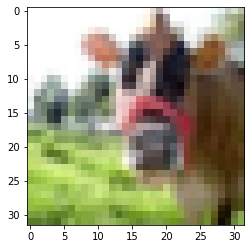

In [12]:
utils.show_np_arr(trainset.ingredients[0])

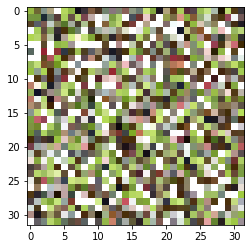

In [13]:
utils.show_np_arr(trainset[0][0])

## 1 - _No mixup/Shuffle only_

In [22]:

USE_CUDA = True
N_EPOCHS = 100
N_BATCHES = None
LR = 0.001

import exp_models

model_getter = lambda: exp_models.resnet18(n=100)

def perform_experiment(lambdas):
    print("saving results in", RESULTS_FNAME)
    print_ = utils.get_print(True, fname=RESULTS_FNAME)
    test_accs = {}
    train_losses = {str(k):[] for k in lambdas}
    val_losses = {str(k):[] for k in lambdas}
    for lambda_ in lambdas:
        print_("Trying lambda=", lambda_)        

        device = torch.device('cuda' if USE_CUDA else 'cpu')        
        model = model_getter().to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=LR)
        criterion = torch.nn.CrossEntropyLoss()
        
        lam_rs = lambda_.reshape((-1, 1, 1, 1, 1))
        lam_rs_tensor = torch.from_numpy(lam_rs).float().to(device)

        NMIX = lam_rs_tensor.shape[0]
        print_("Performing n-mixup with N-mix:", NMIX)

        # Train mode
        model.train()
        for epoch in range(1, N_EPOCHS + 1):
            # Training on all batches
            print_("Epoch[{}/{}]".format(epoch, N_EPOCHS))
            for batch_id, (images, labels) in enumerate(trainloader):
                if N_BATCHES and batch_id > N_BATCHES:
                    break
                labels, images = labels.to(device), images.to(device).float()
                images_mx, ys, perms = utils.mixup_data_nmix(NMIX, images, labels, lam_rs_tensor, device)
                outputs = model(images_mx)
                loss = utils.mixup_criterion_nmix(criterion, outputs, ys, lam_rs_tensor)
                loss_value = loss.item()

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                train_losses[str(lambda_)].append(loss_value)
                if batch_id % 50 == 0:
                    print_('train loss:{:.4f} Epoch[{}/{}] Batch[{}/{}]'.format(
                        loss_value, epoch, N_EPOCHS, batch_id, N_BATCHES_IN_TRAIN_SET))
                    
            # Validating on one batch
            for images, labels in testloader:
                correct = 0
                total = 0
                images = images.to(device).float()
                labels = labels.to(device)
                outputs = model(images)
                predicted = torch.argmax(outputs, dim=1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
                val_acc = 100 * correct / total
                loss = utils.mixup_criterion_nmix(criterion, outputs, ys, lam_rs_tensor)
                loss_value = loss.item()

                print_('val loss:{:.4f} Epoch[{}/{}]'.format(
                        loss_value, epoch, N_EPOCHS))
                print_('val acc:{:.4f} Epoch[{}/{}]'.format(
                        val_acc, epoch, N_EPOCHS))
                val_losses[str(lambda_)].append(loss_value)
                break

        # Test mode
        model.eval()
        with torch.no_grad():
            correct = 0
            total = 0
            for images, labels in testloader:
                images = images.to(device).float()
                labels = labels.to(device)
                outputs = model(images)
                predicted = torch.argmax(outputs, dim=1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
            # Output test accuracy
            test_acc = 100 * correct / total
            print_('Test Accuracy of the model on the test images: {} %'.format(test_acc))
            test_accs[str(lambda_)] = test_acc


        del device, model, optimizer, criterion
    return test_accs, train_losses, val_losses, images_mx, ys


In [11]:
for i in range(1, 5):
    LAMBDAS = [np.array([1.])]
    LAMBDAS = [l/l.sum() for l in LAMBDAS]
    RESULTS_FNAME = "r_cf100_rn18_pshuffleonly_" + str(i)
    with open("results/"+RESULTS_FNAME, "w"):pass
    test_accs, train_losses, val_losses, images_mx, ys = perform_experiment(LAMBDAS)
    print(RESULTS_FNAME, LAMBDAS)

saving results in r_cf100_rn18_pshuffleonly_1
Trying lambda= [1.]
Performing n-mixup with N-mix: 1
Epoch[1/100]
train loss:4.7097 Epoch[1/100] Batch[0/500]
train loss:4.2415 Epoch[1/100] Batch[50/500]
train loss:4.0247 Epoch[1/100] Batch[100/500]
train loss:4.1120 Epoch[1/100] Batch[150/500]
train loss:3.9769 Epoch[1/100] Batch[200/500]
train loss:3.6345 Epoch[1/100] Batch[250/500]
train loss:3.8064 Epoch[1/100] Batch[300/500]
train loss:3.6368 Epoch[1/100] Batch[350/500]
train loss:3.6215 Epoch[1/100] Batch[400/500]
train loss:3.3651 Epoch[1/100] Batch[450/500]
val loss:5.8334 Epoch[1/100]
val acc:8.0000 Epoch[1/100]
Epoch[2/100]
train loss:3.4208 Epoch[2/100] Batch[0/500]
train loss:3.3933 Epoch[2/100] Batch[50/500]
train loss:3.5169 Epoch[2/100] Batch[100/500]
train loss:3.2889 Epoch[2/100] Batch[150/500]
train loss:3.3360 Epoch[2/100] Batch[200/500]
train loss:3.1852 Epoch[2/100] Batch[250/500]
train loss:3.3423 Epoch[2/100] Batch[300/500]
train loss:3.5092 Epoch[2/100] Batch[350/5

train loss:0.1557 Epoch[16/100] Batch[100/500]
train loss:0.1407 Epoch[16/100] Batch[150/500]
train loss:0.1165 Epoch[16/100] Batch[200/500]
train loss:0.1866 Epoch[16/100] Batch[250/500]
train loss:0.1410 Epoch[16/100] Batch[300/500]
train loss:0.1495 Epoch[16/100] Batch[350/500]
train loss:0.1654 Epoch[16/100] Batch[400/500]
train loss:0.1651 Epoch[16/100] Batch[450/500]
val loss:17.7295 Epoch[16/100]
val acc:29.0000 Epoch[16/100]
Epoch[17/100]
train loss:0.3180 Epoch[17/100] Batch[0/500]
train loss:0.0457 Epoch[17/100] Batch[50/500]
train loss:0.1640 Epoch[17/100] Batch[100/500]
train loss:0.1316 Epoch[17/100] Batch[150/500]
train loss:0.1286 Epoch[17/100] Batch[200/500]
train loss:0.1906 Epoch[17/100] Batch[250/500]
train loss:0.0812 Epoch[17/100] Batch[300/500]
train loss:0.1367 Epoch[17/100] Batch[350/500]
train loss:0.1803 Epoch[17/100] Batch[400/500]
train loss:0.1458 Epoch[17/100] Batch[450/500]
val loss:20.5763 Epoch[17/100]
val acc:25.0000 Epoch[17/100]
Epoch[18/100]
train l

train loss:0.0673 Epoch[31/100] Batch[200/500]
train loss:0.0442 Epoch[31/100] Batch[250/500]
train loss:0.0665 Epoch[31/100] Batch[300/500]
train loss:0.0620 Epoch[31/100] Batch[350/500]
train loss:0.1743 Epoch[31/100] Batch[400/500]
train loss:0.1035 Epoch[31/100] Batch[450/500]
val loss:21.8662 Epoch[31/100]
val acc:29.0000 Epoch[31/100]
Epoch[32/100]
train loss:0.0490 Epoch[32/100] Batch[0/500]
train loss:0.0321 Epoch[32/100] Batch[50/500]
train loss:0.0977 Epoch[32/100] Batch[100/500]
train loss:0.0289 Epoch[32/100] Batch[150/500]
train loss:0.0653 Epoch[32/100] Batch[200/500]
train loss:0.0636 Epoch[32/100] Batch[250/500]
train loss:0.0610 Epoch[32/100] Batch[300/500]
train loss:0.1846 Epoch[32/100] Batch[350/500]
train loss:0.0910 Epoch[32/100] Batch[400/500]
train loss:0.0537 Epoch[32/100] Batch[450/500]
val loss:21.6009 Epoch[32/100]
val acc:24.0000 Epoch[32/100]
Epoch[33/100]
train loss:0.0722 Epoch[33/100] Batch[0/500]
train loss:0.1061 Epoch[33/100] Batch[50/500]
train loss

train loss:0.0613 Epoch[46/100] Batch[300/500]
train loss:0.0115 Epoch[46/100] Batch[350/500]
train loss:0.0843 Epoch[46/100] Batch[400/500]
train loss:0.1408 Epoch[46/100] Batch[450/500]
val loss:21.4326 Epoch[46/100]
val acc:28.0000 Epoch[46/100]
Epoch[47/100]
train loss:0.0488 Epoch[47/100] Batch[0/500]
train loss:0.0658 Epoch[47/100] Batch[50/500]
train loss:0.0123 Epoch[47/100] Batch[100/500]
train loss:0.0319 Epoch[47/100] Batch[150/500]
train loss:0.1288 Epoch[47/100] Batch[200/500]
train loss:0.0314 Epoch[47/100] Batch[250/500]
train loss:0.0298 Epoch[47/100] Batch[300/500]
train loss:0.0719 Epoch[47/100] Batch[350/500]
train loss:0.0620 Epoch[47/100] Batch[400/500]
train loss:0.0530 Epoch[47/100] Batch[450/500]
val loss:23.7438 Epoch[47/100]
val acc:30.0000 Epoch[47/100]
Epoch[48/100]
train loss:0.0286 Epoch[48/100] Batch[0/500]
train loss:0.0435 Epoch[48/100] Batch[50/500]
train loss:0.0157 Epoch[48/100] Batch[100/500]
train loss:0.0505 Epoch[48/100] Batch[150/500]
train loss

train loss:0.1452 Epoch[61/100] Batch[400/500]
train loss:0.0851 Epoch[61/100] Batch[450/500]
val loss:24.9921 Epoch[61/100]
val acc:36.0000 Epoch[61/100]
Epoch[62/100]
train loss:0.0026 Epoch[62/100] Batch[0/500]
train loss:0.0038 Epoch[62/100] Batch[50/500]
train loss:0.0092 Epoch[62/100] Batch[100/500]
train loss:0.0026 Epoch[62/100] Batch[150/500]
train loss:0.0047 Epoch[62/100] Batch[200/500]
train loss:0.0137 Epoch[62/100] Batch[250/500]
train loss:0.0064 Epoch[62/100] Batch[300/500]
train loss:0.0282 Epoch[62/100] Batch[350/500]
train loss:0.0040 Epoch[62/100] Batch[400/500]
train loss:0.0799 Epoch[62/100] Batch[450/500]
val loss:24.4803 Epoch[62/100]
val acc:28.0000 Epoch[62/100]
Epoch[63/100]
train loss:0.0365 Epoch[63/100] Batch[0/500]
train loss:0.0189 Epoch[63/100] Batch[50/500]
train loss:0.0245 Epoch[63/100] Batch[100/500]
train loss:0.0084 Epoch[63/100] Batch[150/500]
train loss:0.0166 Epoch[63/100] Batch[200/500]
train loss:0.0292 Epoch[63/100] Batch[250/500]
train loss

...

train loss:0.0437 Epoch[58/100] Batch[400/500]
train loss:0.0455 Epoch[58/100] Batch[450/500]
val loss:21.9153 Epoch[58/100]
val acc:31.0000 Epoch[58/100]
Epoch[59/100]
train loss:0.0758 Epoch[59/100] Batch[0/500]
train loss:0.0189 Epoch[59/100] Batch[50/500]
train loss:0.0080 Epoch[59/100] Batch[100/500]
train loss:0.0510 Epoch[59/100] Batch[150/500]
train loss:0.0122 Epoch[59/100] Batch[200/500]
train loss:0.0280 Epoch[59/100] Batch[250/500]
train loss:0.0070 Epoch[59/100] Batch[300/500]
train loss:0.0538 Epoch[59/100] Batch[350/500]
train loss:0.0063 Epoch[59/100] Batch[400/500]
train loss:0.0484 Epoch[59/100] Batch[450/500]
val loss:22.1606 Epoch[59/100]
val acc:21.0000 Epoch[59/100]
Epoch[60/100]
train loss:0.0277 Epoch[60/100] Batch[0/500]
train loss:0.0344 Epoch[60/100] Batch[50/500]
train loss:0.0709 Epoch[60/100] Batch[100/500]
train loss:0.0124 Epoch[60/100] Batch[150/500]
train loss:0.0072 Epoch[60/100] Batch[200/500]
train loss:0.0044 Epoch[60/100] Batch[250/500]
train loss

val loss:23.1097 Epoch[73/100]
val acc:30.0000 Epoch[73/100]
Epoch[74/100]
train loss:0.0407 Epoch[74/100] Batch[0/500]
train loss:0.0361 Epoch[74/100] Batch[50/500]
train loss:0.0186 Epoch[74/100] Batch[100/500]
train loss:0.0313 Epoch[74/100] Batch[150/500]
train loss:0.0197 Epoch[74/100] Batch[200/500]
train loss:0.0343 Epoch[74/100] Batch[250/500]
train loss:0.0743 Epoch[74/100] Batch[300/500]
train loss:0.0385 Epoch[74/100] Batch[350/500]
train loss:0.0627 Epoch[74/100] Batch[400/500]
train loss:0.0093 Epoch[74/100] Batch[450/500]
val loss:24.0113 Epoch[74/100]
val acc:27.0000 Epoch[74/100]
Epoch[75/100]
train loss:0.0130 Epoch[75/100] Batch[0/500]
train loss:0.0131 Epoch[75/100] Batch[50/500]
train loss:0.0041 Epoch[75/100] Batch[100/500]
train loss:0.0106 Epoch[75/100] Batch[150/500]
train loss:0.0142 Epoch[75/100] Batch[200/500]
train loss:0.0058 Epoch[75/100] Batch[250/500]
train loss:0.0128 Epoch[75/100] Batch[300/500]
train loss:0.0632 Epoch[75/100] Batch[350/500]
train loss

train loss:0.0045 Epoch[89/100] Batch[0/500]
train loss:0.0369 Epoch[89/100] Batch[50/500]
train loss:0.0015 Epoch[89/100] Batch[100/500]
train loss:0.0398 Epoch[89/100] Batch[150/500]
train loss:0.0030 Epoch[89/100] Batch[200/500]
train loss:0.0079 Epoch[89/100] Batch[250/500]
train loss:0.0515 Epoch[89/100] Batch[300/500]
train loss:0.0139 Epoch[89/100] Batch[350/500]
train loss:0.0092 Epoch[89/100] Batch[400/500]
train loss:0.0256 Epoch[89/100] Batch[450/500]
val loss:20.9469 Epoch[89/100]
val acc:27.0000 Epoch[89/100]
Epoch[90/100]
train loss:0.0458 Epoch[90/100] Batch[0/500]
train loss:0.0200 Epoch[90/100] Batch[50/500]
train loss:0.0139 Epoch[90/100] Batch[100/500]
train loss:0.0021 Epoch[90/100] Batch[150/500]
train loss:0.0443 Epoch[90/100] Batch[200/500]
train loss:0.0053 Epoch[90/100] Batch[250/500]
train loss:0.0108 Epoch[90/100] Batch[300/500]
train loss:0.0173 Epoch[90/100] Batch[350/500]
train loss:0.0332 Epoch[90/100] Batch[400/500]
train loss:0.0131 Epoch[90/100] Batch[

val loss:7.1493 Epoch[3/100]
val acc:28.0000 Epoch[3/100]
Epoch[4/100]
train loss:2.9236 Epoch[4/100] Batch[0/500]
train loss:2.7111 Epoch[4/100] Batch[50/500]
train loss:2.6896 Epoch[4/100] Batch[100/500]
train loss:2.7698 Epoch[4/100] Batch[150/500]
train loss:2.6376 Epoch[4/100] Batch[200/500]
train loss:2.7375 Epoch[4/100] Batch[250/500]
train loss:3.0354 Epoch[4/100] Batch[300/500]
train loss:2.8288 Epoch[4/100] Batch[350/500]
train loss:3.0361 Epoch[4/100] Batch[400/500]
train loss:2.7646 Epoch[4/100] Batch[450/500]
val loss:7.4075 Epoch[4/100]
val acc:27.0000 Epoch[4/100]
Epoch[5/100]
train loss:2.5537 Epoch[5/100] Batch[0/500]
train loss:2.6122 Epoch[5/100] Batch[50/500]
train loss:2.5078 Epoch[5/100] Batch[100/500]
train loss:2.5805 Epoch[5/100] Batch[150/500]
train loss:2.3838 Epoch[5/100] Batch[200/500]
train loss:2.3612 Epoch[5/100] Batch[250/500]
train loss:2.9430 Epoch[5/100] Batch[300/500]
train loss:2.6519 Epoch[5/100] Batch[350/500]
train loss:2.3396 Epoch[5/100] Batch

KeyboardInterrupt: 

## 2 - _Shuffle+mixup, CIFAR10_

In [14]:
for n in range(2, 6):
    N = n
    L = 1
    LAMBDAS = np.array([[3/(4**(i+1)) for i in range(N-1)] + [.25**(N-1)]])
    LAMBDAS = [l/l.sum() for l in LAMBDAS]
    RESULTS_FNAME = "r_cf10_rn18_n"+str(n)+"_pshuffle_mixup_sweetspot"
    with open("results/"+RESULTS_FNAME, "w"):pass
    test_accs, train_losses, val_losses, images_mx, ys = perform_experiment(LAMBDAS)
    print(RESULTS_FNAME, LAMBDAS)
    
    LAMBDAS = [np.ones(N) for _ in range(L)]
    LAMBDAS = [l/l.sum() for l in LAMBDAS]
    RESULTS_FNAME = "r_cf10_rn18_n"+str(n)+"_pshuffle_mixup_maxobf"
    with open("results/"+RESULTS_FNAME, "w"):pass
    test_accs, train_losses, val_losses, images_mx, ys = perform_experiment(LAMBDAS)
    print(RESULTS_FNAME, LAMBDAS)
    

saving results in r_cf10_rn18_n2_pshuffle_mixup_maxobf_DELETE
Trying lambda= [0.5 0.5]
Performing n-mixup with N-mix: 2
Epoch[1/1]
train loss:4.7709 Epoch[1/1] Batch[0/500]
val loss:4.7009 Epoch[1/1]
val acc:0.0000 Epoch[1/1]
Test Accuracy of the model on the test images: 1.0 %
r_cf10_rn18_n2_pshuffle_mixup_maxobf_DELETE [array([0.5, 0.5])]


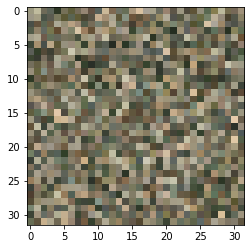

In [19]:
utils.show_np_arr(images_mx[0].cpu())

## 3 - _Shuffle+mixup, CIFAR100_

In [4]:


transform = torchvision.transforms.transforms.Compose([
    torchvision.transforms.transforms.ToTensor()
])

base_trainset = torchvision.datasets.CIFAR100(root='/data/landelle/datasets', train=True, download=True, transform=transform)
base_testset = torchvision.datasets.CIFAR100(root='/data/landelle/datasets', train=False, download=True, transform=transform)

BATCH_SIZE = 100
N_BATCHES_IN_TRAIN_SET = len(base_trainset) // BATCH_SIZE
N_BATCHES_IN_TEST_SET = len(base_trainset) // BATCH_SIZE
NUM_WORKERS = 8

trainset = PixelShuffler(base_trainset,
                                2019,
                                sample_size=50000,
                                transform=transform)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)

testset = PixelShuffler(base_testset,
                        2019,
                        preset_masks=trainset.pmix_masks,
                        transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)


Files already downloaded and verified
Files already downloaded and verified
b
c
d
Labels: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71
 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95
 96 97 98 99] => n_unique: 100
g
b
c
d
Labels: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71
 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95
 96 97 98 99] => n_unique: 100
g


In [8]:

model_getter = lambda: exp_models.resnet18(n=100)

In [ ]:
for n in range(2, 6):
    N = n
    L = 1
    #LAMBDAS = [np.array([1/(x**n) for n in range(N)]) for x in np.linspace(1., 6., L+1)]
    #LAMBDAS = [np.ones(N) for _ in range(L)]
    LAMBDAS = np.array([[3/(4**(i+1)) for i in range(N-1)] + [.25**(N-1)]])
    #LAMBDAS = [np.array([1.])]
    LAMBDAS = [l/l.sum() for l in LAMBDAS]
    RESULTS_FNAME = "r_cf100_rn18_n"+str(n)+"_pshuffle_mixup_sweetspot"
    with open("results/"+RESULTS_FNAME, "w"):pass
    test_accs, train_losses, val_losses, images_mx, ys = perform_experiment(LAMBDAS)
    print(RESULTS_FNAME, LAMBDAS)
    
    LAMBDAS = [np.ones(N) for _ in range(L)]
    LAMBDAS = [l/l.sum() for l in LAMBDAS]
    RESULTS_FNAME = "r_cf100_rn18_n"+str(n)+"_pshuffle_mixup_maxobf"
    with open("results/"+RESULTS_FNAME, "w"):pass
    test_accs, train_losses, val_losses, images_mx, ys = perform_experiment(LAMBDAS)
    print(RESULTS_FNAME, LAMBDAS)

saving results in r_cf100_rn18_n2_pshuffle_mixup_sweetspot
Trying lambda= [0.75 0.25]
Performing n-mixup with N-mix: 2
Epoch[1/100]
train loss:4.7365 Epoch[1/100] Batch[0/500]
train loss:4.4113 Epoch[1/100] Batch[50/500]
train loss:4.3581 Epoch[1/100] Batch[100/500]
train loss:4.2362 Epoch[1/100] Batch[150/500]
train loss:4.2606 Epoch[1/100] Batch[200/500]
train loss:4.1711 Epoch[1/100] Batch[250/500]
train loss:3.9702 Epoch[1/100] Batch[300/500]
train loss:4.0815 Epoch[1/100] Batch[350/500]
train loss:4.0049 Epoch[1/100] Batch[400/500]
train loss:4.0807 Epoch[1/100] Batch[450/500]
val loss:5.0873 Epoch[1/100]
val acc:15.0000 Epoch[1/100]
Epoch[2/100]
train loss:3.9113 Epoch[2/100] Batch[0/500]
train loss:4.0447 Epoch[2/100] Batch[50/500]
train loss:4.0333 Epoch[2/100] Batch[100/500]
train loss:3.9388 Epoch[2/100] Batch[150/500]
train loss:3.9868 Epoch[2/100] Batch[200/500]
train loss:3.9120 Epoch[2/100] Batch[250/500]
train loss:3.9651 Epoch[2/100] Batch[300/500]
train loss:3.8862 Epo

train loss:2.4077 Epoch[16/100] Batch[100/500]
train loss:2.3953 Epoch[16/100] Batch[150/500]
train loss:2.4415 Epoch[16/100] Batch[200/500]
train loss:2.4106 Epoch[16/100] Batch[250/500]
train loss:2.4605 Epoch[16/100] Batch[300/500]
train loss:2.4434 Epoch[16/100] Batch[350/500]
train loss:2.5705 Epoch[16/100] Batch[400/500]
train loss:2.4717 Epoch[16/100] Batch[450/500]
val loss:6.0149 Epoch[16/100]
val acc:36.0000 Epoch[16/100]
Epoch[17/100]
train loss:2.3503 Epoch[17/100] Batch[0/500]
train loss:2.2480 Epoch[17/100] Batch[50/500]
train loss:2.3273 Epoch[17/100] Batch[100/500]
train loss:2.3180 Epoch[17/100] Batch[150/500]
train loss:2.2475 Epoch[17/100] Batch[200/500]
train loss:2.4395 Epoch[17/100] Batch[250/500]
train loss:2.4170 Epoch[17/100] Batch[300/500]
train loss:2.3315 Epoch[17/100] Batch[350/500]
train loss:2.3934 Epoch[17/100] Batch[400/500]
train loss:2.4564 Epoch[17/100] Batch[450/500]
val loss:5.7580 Epoch[17/100]
val acc:34.0000 Epoch[17/100]
Epoch[18/100]
train los

train loss:1.9959 Epoch[31/100] Batch[200/500]
train loss:2.0426 Epoch[31/100] Batch[250/500]
train loss:2.0133 Epoch[31/100] Batch[300/500]
train loss:2.0682 Epoch[31/100] Batch[350/500]
train loss:1.9785 Epoch[31/100] Batch[400/500]
train loss:1.9803 Epoch[31/100] Batch[450/500]
val loss:5.6105 Epoch[31/100]
val acc:35.0000 Epoch[31/100]
Epoch[32/100]
train loss:1.8640 Epoch[32/100] Batch[0/500]
train loss:1.9412 Epoch[32/100] Batch[50/500]
train loss:2.0101 Epoch[32/100] Batch[100/500]
train loss:1.8877 Epoch[32/100] Batch[150/500]
train loss:1.9853 Epoch[32/100] Batch[200/500]
train loss:2.0669 Epoch[32/100] Batch[250/500]
train loss:2.0529 Epoch[32/100] Batch[300/500]
train loss:1.9956 Epoch[32/100] Batch[350/500]
train loss:2.0135 Epoch[32/100] Batch[400/500]
train loss:1.9808 Epoch[32/100] Batch[450/500]
val loss:5.4033 Epoch[32/100]
val acc:36.0000 Epoch[32/100]
Epoch[33/100]
train loss:1.8985 Epoch[33/100] Batch[0/500]
train loss:1.9885 Epoch[33/100] Batch[50/500]
train loss:1

train loss:1.8393 Epoch[46/100] Batch[300/500]
train loss:1.8952 Epoch[46/100] Batch[350/500]
train loss:1.9070 Epoch[46/100] Batch[400/500]
train loss:1.9295 Epoch[46/100] Batch[450/500]
val loss:5.5027 Epoch[46/100]
val acc:35.0000 Epoch[46/100]
Epoch[47/100]
train loss:1.8652 Epoch[47/100] Batch[0/500]
train loss:1.8682 Epoch[47/100] Batch[50/500]
train loss:1.8632 Epoch[47/100] Batch[100/500]
train loss:1.8471 Epoch[47/100] Batch[150/500]
train loss:1.8822 Epoch[47/100] Batch[200/500]
train loss:1.8215 Epoch[47/100] Batch[250/500]
train loss:1.8282 Epoch[47/100] Batch[300/500]
train loss:1.9663 Epoch[47/100] Batch[350/500]
train loss:1.8976 Epoch[47/100] Batch[400/500]
train loss:1.8678 Epoch[47/100] Batch[450/500]
val loss:5.5725 Epoch[47/100]
val acc:33.0000 Epoch[47/100]
Epoch[48/100]
train loss:1.8274 Epoch[48/100] Batch[0/500]
train loss:1.8225 Epoch[48/100] Batch[50/500]
train loss:1.9109 Epoch[48/100] Batch[100/500]
train loss:1.9135 Epoch[48/100] Batch[150/500]
train loss:1

train loss:1.8229 Epoch[61/100] Batch[400/500]
train loss:1.8129 Epoch[61/100] Batch[450/500]
val loss:5.6349 Epoch[61/100]
val acc:36.0000 Epoch[61/100]
Epoch[62/100]
train loss:1.7985 Epoch[62/100] Batch[0/500]
train loss:1.7596 Epoch[62/100] Batch[50/500]
train loss:1.7343 Epoch[62/100] Batch[100/500]
train loss:1.8470 Epoch[62/100] Batch[150/500]
train loss:1.7960 Epoch[62/100] Batch[200/500]
train loss:1.8780 Epoch[62/100] Batch[250/500]
train loss:1.7523 Epoch[62/100] Batch[300/500]
train loss:1.9064 Epoch[62/100] Batch[350/500]
train loss:1.7913 Epoch[62/100] Batch[400/500]
train loss:1.8288 Epoch[62/100] Batch[450/500]
val loss:5.3826 Epoch[62/100]
val acc:38.0000 Epoch[62/100]
Epoch[63/100]
train loss:1.7615 Epoch[63/100] Batch[0/500]
train loss:1.7461 Epoch[63/100] Batch[50/500]
train loss:1.7516 Epoch[63/100] Batch[100/500]
train loss:1.7304 Epoch[63/100] Batch[150/500]
train loss:1.8154 Epoch[63/100] Batch[200/500]
train loss:1.7975 Epoch[63/100] Batch[250/500]
train loss:1

...

train loss:4.2701 Epoch[27/100] Batch[300/500]
train loss:4.2063 Epoch[27/100] Batch[350/500]
train loss:4.3173 Epoch[27/100] Batch[400/500]
train loss:4.2808 Epoch[27/100] Batch[450/500]
val loss:5.1517 Epoch[27/100]
val acc:23.0000 Epoch[27/100]
Epoch[28/100]
train loss:4.1997 Epoch[28/100] Batch[0/500]
train loss:4.2988 Epoch[28/100] Batch[50/500]
train loss:4.2763 Epoch[28/100] Batch[100/500]
train loss:4.2095 Epoch[28/100] Batch[150/500]
train loss:4.2102 Epoch[28/100] Batch[200/500]
train loss:4.2333 Epoch[28/100] Batch[250/500]
train loss:4.2214 Epoch[28/100] Batch[300/500]
train loss:4.2648 Epoch[28/100] Batch[350/500]
train loss:4.2020 Epoch[28/100] Batch[400/500]
train loss:4.2736 Epoch[28/100] Batch[450/500]
val loss:5.0943 Epoch[28/100]
val acc:26.0000 Epoch[28/100]
Epoch[29/100]
train loss:4.2145 Epoch[29/100] Batch[0/500]
train loss:4.2293 Epoch[29/100] Batch[50/500]
train loss:4.2298 Epoch[29/100] Batch[100/500]
train loss:4.2571 Epoch[29/100] Batch[150/500]
train loss:4

train loss:4.2117 Epoch[42/100] Batch[400/500]
train loss:4.1860 Epoch[42/100] Batch[450/500]
val loss:5.1130 Epoch[42/100]
val acc:22.0000 Epoch[42/100]
Epoch[43/100]
train loss:4.1616 Epoch[43/100] Batch[0/500]
train loss:4.2387 Epoch[43/100] Batch[50/500]
train loss:4.1206 Epoch[43/100] Batch[100/500]
train loss:4.0844 Epoch[43/100] Batch[150/500]
train loss:4.2809 Epoch[43/100] Batch[200/500]
train loss:4.1313 Epoch[43/100] Batch[250/500]
train loss:4.3025 Epoch[43/100] Batch[300/500]
train loss:4.2328 Epoch[43/100] Batch[350/500]
train loss:4.2490 Epoch[43/100] Batch[400/500]
train loss:4.2483 Epoch[43/100] Batch[450/500]
val loss:5.1353 Epoch[43/100]
val acc:25.0000 Epoch[43/100]
Epoch[44/100]
train loss:4.0450 Epoch[44/100] Batch[0/500]
train loss:4.0609 Epoch[44/100] Batch[50/500]
train loss:4.1959 Epoch[44/100] Batch[100/500]
train loss:4.1451 Epoch[44/100] Batch[150/500]
train loss:4.1925 Epoch[44/100] Batch[200/500]
train loss:4.0730 Epoch[44/100] Batch[250/500]
train loss:4

val loss:5.3293 Epoch[57/100]
val acc:27.0000 Epoch[57/100]
Epoch[58/100]
train loss:4.0598 Epoch[58/100] Batch[0/500]
train loss:4.1593 Epoch[58/100] Batch[50/500]
train loss:4.1163 Epoch[58/100] Batch[100/500]
train loss:4.0353 Epoch[58/100] Batch[150/500]
train loss:4.0493 Epoch[58/100] Batch[200/500]
train loss:4.1325 Epoch[58/100] Batch[250/500]
train loss:4.2004 Epoch[58/100] Batch[300/500]
train loss:4.1045 Epoch[58/100] Batch[350/500]
train loss:3.9912 Epoch[58/100] Batch[400/500]
train loss:4.1472 Epoch[58/100] Batch[450/500]
val loss:5.3797 Epoch[58/100]
val acc:28.0000 Epoch[58/100]
Epoch[59/100]
train loss:4.0746 Epoch[59/100] Batch[0/500]
train loss:4.0297 Epoch[59/100] Batch[50/500]
train loss:4.0427 Epoch[59/100] Batch[100/500]
train loss:4.1274 Epoch[59/100] Batch[150/500]
train loss:4.0113 Epoch[59/100] Batch[200/500]
train loss:4.0470 Epoch[59/100] Batch[250/500]
train loss:4.0546 Epoch[59/100] Batch[300/500]
train loss:4.1517 Epoch[59/100] Batch[350/500]
train loss:4

train loss:4.0956 Epoch[73/100] Batch[50/500]
train loss:4.0169 Epoch[73/100] Batch[100/500]
train loss:3.9315 Epoch[73/100] Batch[150/500]
train loss:4.0587 Epoch[73/100] Batch[200/500]
train loss:4.0228 Epoch[73/100] Batch[250/500]
train loss:4.1414 Epoch[73/100] Batch[300/500]
train loss:4.0930 Epoch[73/100] Batch[350/500]
train loss:4.1260 Epoch[73/100] Batch[400/500]
train loss:4.0723 Epoch[73/100] Batch[450/500]
val loss:5.0377 Epoch[73/100]
val acc:28.0000 Epoch[73/100]
Epoch[74/100]
train loss:4.0379 Epoch[74/100] Batch[0/500]
train loss:4.0364 Epoch[74/100] Batch[50/500]
train loss:4.0611 Epoch[74/100] Batch[100/500]
train loss:3.9538 Epoch[74/100] Batch[150/500]
train loss:4.0516 Epoch[74/100] Batch[200/500]
train loss:3.9350 Epoch[74/100] Batch[250/500]
train loss:4.0222 Epoch[74/100] Batch[300/500]
train loss:4.0627 Epoch[74/100] Batch[350/500]
train loss:3.9775 Epoch[74/100] Batch[400/500]
train loss:4.0869 Epoch[74/100] Batch[450/500]
val loss:5.2458 Epoch[74/100]
val acc

train loss:4.0518 Epoch[88/100] Batch[150/500]
train loss:4.0093 Epoch[88/100] Batch[200/500]
train loss:3.9604 Epoch[88/100] Batch[250/500]
train loss:4.1006 Epoch[88/100] Batch[300/500]
train loss:4.0222 Epoch[88/100] Batch[350/500]
train loss:3.9640 Epoch[88/100] Batch[400/500]
train loss:4.0701 Epoch[88/100] Batch[450/500]
val loss:5.3151 Epoch[88/100]
val acc:28.0000 Epoch[88/100]
Epoch[89/100]
train loss:4.0532 Epoch[89/100] Batch[0/500]
train loss:3.9454 Epoch[89/100] Batch[50/500]
train loss:4.0085 Epoch[89/100] Batch[100/500]
train loss:4.0054 Epoch[89/100] Batch[150/500]
train loss:3.9447 Epoch[89/100] Batch[200/500]
train loss:3.9162 Epoch[89/100] Batch[250/500]
train loss:4.0787 Epoch[89/100] Batch[300/500]
train loss:3.9906 Epoch[89/100] Batch[350/500]
train loss:4.0987 Epoch[89/100] Batch[400/500]
train loss:3.9933 Epoch[89/100] Batch[450/500]
val loss:5.4078 Epoch[89/100]
val acc:30.0000 Epoch[89/100]
Epoch[90/100]
train loss:3.9764 Epoch[90/100] Batch[0/500]
train loss:

## 4 - Generate visualizations

In [48]:

USE_CUDA = True
N_EPOCHS = 1
N_BATCHES = 1
LR = 0.001

import exp_models

model_getter = lambda: exp_models.resnet18(n=100)

class PixelShufflerVisual(torch.utils.data.Dataset):

    def __init__(self, base_set, pmix_seed, *, preset_masks=None, sample_size=None, transform=None):
        print("b")
        self.transform = transform        
        
        L = sample_size if sample_size else base_set.data.shape[0]
        imgs = np.array(base_set.data[:L])
        
        print("c")
        imgs = np.float32(imgs/255.)
        imgs = imgs.transpose((0, 3, 1, 2))
        
        print("d")
        labels = np.array(base_set.targets[:L])
        unique = np.unique(labels)
        n_unique = unique.shape[0]
        print("Labels:", unique, "=> n_unique:", n_unique)
        
        self.ingredients = imgs #[imgs[0]]

        print("g")
        self.pmix_masks = pixel_shuffle_masks(n_unique, imgs.shape[2:4], True) if preset_masks is None else preset_masks
        self.pmixed = pixel_shuffle_images(imgs, labels, self.pmix_masks)
        self.labels = labels
        #show_np_array(mixed[0])
        

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.tolist()
        ingr = self.ingredients[idx]
        img = self.pmixed[idx]
        target = self.labels[idx]
        
        if self.transform is not None:
            img = self.transform(img).transpose(1, 0).transpose(1, 2)
            if not img.shape == (3, 32, 32):
                raise Exception()
        return img, target, ingr
    
BATCH_SIZE = 100
N_BATCHES_IN_TRAIN_SET = len(base_trainset) // BATCH_SIZE
N_BATCHES_IN_TEST_SET = len(base_trainset) // BATCH_SIZE
NUM_WORKERS = 8

trainset = PixelShufflerVisual(base_trainset,
                                2019,
                                sample_size=50000,
                                transform=transform)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)

testset = PixelShufflerVisual(base_testset,
                        2019,
                        preset_masks=trainset.pmix_masks,
                        transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
    
def perform_experiment_getvisuals(lambdas):
    print("saving results in", RESULTS_FNAME)
    print_ = utils.get_print(True, fname=RESULTS_FNAME)
    test_accs = {}
    train_losses = {str(k):[] for k in lambdas}
    val_losses = {str(k):[] for k in lambdas}
    for lambda_ in lambdas:
        print_("Trying lambda=", lambda_)        

        device = torch.device('cuda' if USE_CUDA else 'cpu')        
        model = model_getter().to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=LR)
        criterion = torch.nn.CrossEntropyLoss()
        
        lam_rs = lambda_.reshape((-1, 1, 1, 1, 1))
        lam_rs_tensor = torch.from_numpy(lam_rs).float().to(device)

        NMIX = lam_rs_tensor.shape[0]
        print_("Performing n-mixup with N-mix:", NMIX)

        # Train mode
        model.train()
        for epoch in range(1, N_EPOCHS + 1):
            # Training on all batches
            print_("Epoch[{}/{}]".format(epoch, N_EPOCHS))
            for batch_id, (images, labels, ingredients) in enumerate(trainloader):
                if N_BATCHES and batch_id > N_BATCHES:
                    break
                labels, images = labels.to(device), images.to(device).float()
                images_mx, ys, perms = utils.mixup_data_nmix(NMIX, images, labels, lam_rs_tensor, device)
                print("ok")
                return images, images_mx, perms, ingredients
                outputs = model(images_mx)
                loss = utils.mixup_criterion_nmix(criterion, outputs, ys, lam_rs_tensor)
                loss_value = loss.item()

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                train_losses[str(lambda_)].append(loss_value)
                if batch_id % 50 == 0:
                    print_('train loss:{:.4f} Epoch[{}/{}] Batch[{}/{}]'.format(
                        loss_value, epoch, N_EPOCHS, batch_id, N_BATCHES_IN_TRAIN_SET))
                    
            # Validating on one batch
            for images, labels in testloader:
                correct = 0
                total = 0
                images = images.to(device).float()
                labels = labels.to(device)
                outputs = model(images)
                predicted = torch.argmax(outputs, dim=1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
                val_acc = 100 * correct / total
                loss = utils.mixup_criterion_nmix(criterion, outputs, ys, lam_rs_tensor)
                loss_value = loss.item()

                print_('val loss:{:.4f} Epoch[{}/{}]'.format(
                        loss_value, epoch, N_EPOCHS))
                print_('val acc:{:.4f} Epoch[{}/{}]'.format(
                        val_acc, epoch, N_EPOCHS))
                val_losses[str(lambda_)].append(loss_value)
                break

        # Test mode
        model.eval()
        with torch.no_grad():
            correct = 0
            total = 0
            for images, labels in testloader:
                images = images.to(device).float()
                labels = labels.to(device)
                outputs = model(images)
                predicted = torch.argmax(outputs, dim=1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
            # Output test accuracy
            test_acc = 100 * correct / total
            print_('Test Accuracy of the model on the test images: {} %'.format(test_acc))
            test_accs[str(lambda_)] = test_acc


        del device, model, optimizer, criterion
    return test_accs, train_losses, val_losses, images_mx, ys


b
c
d
Labels: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71
 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95
 96 97 98 99] => n_unique: 100
g
b
c
d
Labels: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71
 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95
 96 97 98 99] => n_unique: 100
g


In [49]:
for n in range(2, 6):    
    LAMBDAS = [np.ones(N) for _ in range(L)]
    LAMBDAS = [l/l.sum() for l in LAMBDAS]
    RESULTS_FNAME = "r_cf10_rn18_n"+str(n)+"_pshuffle_mixup_visual_DELETE"
    with open("results/"+RESULTS_FNAME, "w"):pass
    images, images_mx, perms, ingredients = perform_experiment_getvisuals(LAMBDAS)
    print(RESULTS_FNAME, LAMBDAS)
    break

saving results in r_cf10_rn18_n2_pshuffle_mixup_visual_DELETE
Trying lambda= [0.5 0.5]
Performing n-mixup with N-mix: 2
Epoch[1/1]
ok
r_cf10_rn18_n2_pshuffle_mixup_visual_DELETE [array([0.5, 0.5])]


In [37]:
perms

[array([88, 35, 10,  8, 33,  1, 62, 95, 53, 54, 94, 93, 22, 82, 21, 20, 61,
        49,  4, 71,  9, 83, 90, 48,  7, 17, 77, 59, 16, 12,  0, 14, 79, 80,
        23,  3, 46, 45,  2, 58, 52, 97, 44, 43, 85, 73, 69, 91, 87, 37, 36,
        24, 27, 89, 86, 70, 76, 34, 15, 84, 29, 65, 96, 68,  5, 42, 28, 66,
        75, 18, 25, 60, 41, 51, 31, 78, 63, 38, 32, 99,  6, 19, 11, 67, 50,
        98, 64, 56, 81, 47, 72, 40, 74, 55, 13, 30, 39, 92, 57, 26]),
 array([38, 42, 11, 96, 28,  0,  7, 53, 99, 60, 40, 92, 90, 39, 13, 23, 19,
        43, 34, 79, 61, 70, 29, 71, 75, 48, 57, 85, 35, 24, 76,  1, 15,  8,
        18, 41, 68, 58, 91, 67, 80, 78, 14, 21, 33, 87,  2, 84, 26, 30, 72,
        63, 20, 69,  5, 77, 45, 12, 22, 88, 89, 44, 64, 95, 49, 31, 59, 93,
        25,  9, 37, 52, 32, 54, 17, 94, 46,  6, 51, 73,  4, 65, 97, 27, 36,
        50, 16, 66, 82, 62, 81,  3, 83, 86, 10, 55, 56, 74, 98, 47])]

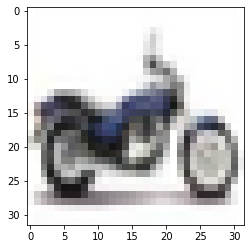

In [51]:
utils.show_np_arr(ingredients[perms[0][0]].cpu())


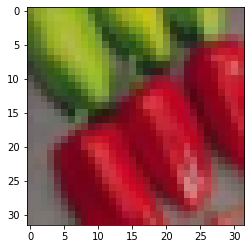

In [53]:
utils.show_np_arr(ingredients[perms[1][0]].cpu())


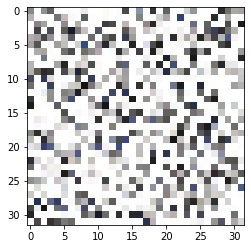

In [54]:
utils.show_np_arr(images[perms[0][0]].cpu())


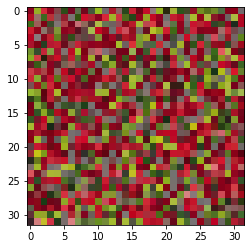

In [55]:
utils.show_np_arr(images[perms[1][0]].cpu())


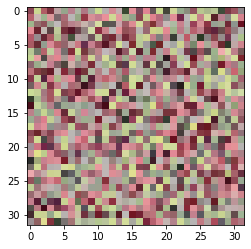

In [56]:
utils.show_np_arr(images_mx[0].cpu())